### Exploratory Data Analysis
**E-Commerce Demand Forecasting & Supply Chain Optimization**

- `store_demand.csv` — 5 years daily sales, 50 items, 10 stores
- `online_retail.csv` — Transactional retail data with pricing, quantity, country

In [19]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
print('Libraries loaded')

Libraries loaded


In [20]:
# Cell 2 — Load Data
demand = pd.read_csv('../data/raw/store_demand.csv', parse_dates=['date'])
retail = pd.read_csv('../data/raw/online_retail.csv')

print('Demand shape:', demand.shape)
print('Retail shape:', retail.shape)
print()
display(demand.head(3))
display(retail.head(3))

Demand shape: (913000, 4)
Retail shape: (1067371, 8)



,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [21]:
# Cell 3 — Data Quality Check
print('=== DEMAND ===')
print('Missing values:')
print(demand.isnull().sum())
print('Date range  :', demand['date'].min(), '→', demand['date'].max())
print('Stores      :', demand['store'].nunique())
print('Items       :', demand['item'].nunique())
print('Total rows  :', len(demand))

print()
print('=== RETAIL ===')
print('Missing values:')
print(retail.isnull().sum())
print('Unique customers :', retail['Customer ID'].nunique())
print('Unique products  :', retail['StockCode'].nunique())
print('Countries        :', retail['Country'].nunique())

=== DEMAND ===
Missing values:
date     0
store    0
item     0
sales    0
dtype: int64
Date range  : 2013-01-01 00:00:00 → 2017-12-31 00:00:00
Stores      : 10
Items       : 50
Total rows  : 913000

=== RETAIL ===
Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64
Unique customers : 5942
Unique products  : 5305
Countries        : 43


In [22]:
# Cell 4 — Clean Retail Data
retail = retail.dropna(subset=['Customer ID'])
retail = retail[retail['Quantity'] > 0]
retail = retail[retail['Price'] > 0]
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'], infer_datetime_format=True)
retail['Revenue']     = retail['Quantity'] * retail['Price']
retail['date']        = retail['InvoiceDate'].dt.normalize()
retail['month']       = retail['InvoiceDate'].dt.month
retail['year']        = retail['InvoiceDate'].dt.year

print('Cleaned retail shape:', retail.shape)
print('Total revenue       : $', round(retail['Revenue'].sum(), 2))
print('Date range          :', retail['date'].min(), '→', retail['date'].max())

Cleaned retail shape: (805549, 12)
Total revenue       : $ 17743429.18
Date range          : 2009-12-01 00:00:00 → 2011-12-09 00:00:00


In [23]:
# Cell 5 — Add Time Features to Demand
demand['year']    = demand['date'].dt.year
demand['month']   = demand['date'].dt.month
demand['dow']     = demand['date'].dt.dayofweek
demand['week']    = demand['date'].dt.isocalendar().week.astype(int)
demand['quarter'] = demand['date'].dt.quarter

print('Time features added')
demand.head(3)

Time features added


,date,store,item,sales,year,month,dow,week,quarter
0,2013-01-01,1,1,13,2013,1,1,1,1
1,2013-01-02,1,1,11,2013,1,2,1,1
2,2013-01-03,1,1,14,2013,1,3,1,1


In [24]:
# Cell 6 — Daily Sales Trend
daily_sales = demand.groupby('date')['sales'].sum().reset_index()

fig = px.line(daily_sales, x='date', y='sales',
              title='Daily Total Sales — All Stores (5 Years)',
              labels={'sales': 'Total Sales', 'date': 'Date'},
              color_discrete_sequence=['#1a936f'])
fig.update_layout(height=400, plot_bgcolor='white', paper_bgcolor='white',
                  xaxis=dict(showgrid=False), yaxis=dict(gridcolor='#f0f0f0'))
fig.show()

In [25]:
# Cell 7 — Seasonality: Monthly & Day of Week
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg = demand.groupby('month')['sales'].mean().reset_index()
monthly_avg['month_name'] = monthly_avg['month'].apply(lambda x: month_names[x-1])

dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_avg   = demand.groupby('dow')['sales'].mean().reset_index()
dow_avg['day'] = dow_avg['dow'].apply(lambda x: dow_names[x])

fig1 = px.bar(monthly_avg, x='month_name', y='sales',
              title='Average Sales by Month — Seasonality Pattern',
              labels={'sales': 'Avg Sales', 'month_name': 'Month'},
              color='sales', color_continuous_scale='RdYlGn')
fig1.update_layout(height=380, plot_bgcolor='white', paper_bgcolor='white')
fig1.show()

fig2 = px.line(dow_avg, x='day', y='sales', markers=True,
               title='Average Sales by Day of Week',
               labels={'sales': 'Avg Sales', 'day': 'Day'},
               color_discrete_sequence=['#e74c3c'])
fig2.update_layout(height=350, plot_bgcolor='white', paper_bgcolor='white')
fig2.show()

In [26]:
# Cell 8 — Store & Item Performance
store_perf = demand.groupby('store')['sales'].sum().reset_index().sort_values('sales', ascending=False)
item_perf  = demand.groupby('item')['sales'].sum().reset_index().sort_values('sales', ascending=False).head(10)

fig1 = px.bar(store_perf, x='store', y='sales',
              title='Total Sales by Store',
              labels={'sales': 'Total Sales', 'store': 'Store ID'},
              color='sales', color_continuous_scale='Blues')
fig1.update_layout(height=370, plot_bgcolor='white', paper_bgcolor='white')
fig1.show()

fig2 = px.bar(item_perf, x='item', y='sales',
              title='Top 10 Items by Total Sales',
              labels={'sales': 'Total Sales', 'item': 'Item ID'},
              color='sales', color_continuous_scale='Greens')
fig2.update_layout(height=370, plot_bgcolor='white', paper_bgcolor='white')
fig2.show()

In [27]:
# Cell 9 — Revenue Analysis (Online Retail)
daily_rev  = retail.groupby('date')['Revenue'].sum().reset_index().sort_values('date')
country_rev = retail.groupby('Country')['Revenue'].sum().reset_index().sort_values('Revenue', ascending=False).head(10)

fig1 = px.area(daily_rev, x='date', y='Revenue',
               title='Daily Revenue Trend — Online Retail',
               labels={'Revenue': 'Revenue ($)', 'date': 'Date'},
               color_discrete_sequence=['#9b59b6'])
fig1.update_layout(height=400, plot_bgcolor='white', paper_bgcolor='white',
                   xaxis=dict(showgrid=False), yaxis=dict(gridcolor='#f0f0f0'))
fig1.show()

fig2 = px.bar(country_rev, x='Country', y='Revenue',
              title='Top 10 Countries by Revenue',
              labels={'Revenue': 'Total Revenue ($)'},
              color='Revenue', color_continuous_scale='Purples')
fig2.update_layout(height=380, plot_bgcolor='white', paper_bgcolor='white')
fig2.show()

In [28]:
# Cell 10 — Price Elasticity Analysis
price_qty = retail.groupby('Price').agg({'Quantity': 'sum'}).reset_index()
price_qty = price_qty[price_qty['Price'] < price_qty['Price'].quantile(0.95)]

log_price = np.log(price_qty['Price'] + 1)
log_qty   = np.log(price_qty['Quantity'] + 1)
slope, intercept, r, p, se = stats.linregress(log_price, log_qty)

print('=== Price Elasticity ===')
print(f'Elasticity Coefficient : {slope:.3f}')
print(f'R-squared              : {r**2:.3f}')
print(f'P-value                : {p:.4f}')
print()
if slope < -1:
    print('→ Elastic demand: customers are price-sensitive')
elif slope < 0:
    print('→ Inelastic demand: customers are not very price-sensitive')
else:
    print('→ Positive relationship detected')

fig = px.scatter(price_qty, x='Price', y='Quantity', trendline='ols',
                 title='Price vs Quantity Sold — Price Elasticity',
                 labels={'Price': 'Unit Price ($)', 'Quantity': 'Total Qty Sold'},
                 color_discrete_sequence=['#e74c3c'])
fig.update_layout(height=400, plot_bgcolor='white', paper_bgcolor='white')
fig.show()

=== Price Elasticity ===
Elasticity Coefficient : -1.400
R-squared              : 0.578
P-value                : 0.0000

→ Elastic demand: customers are price-sensitive


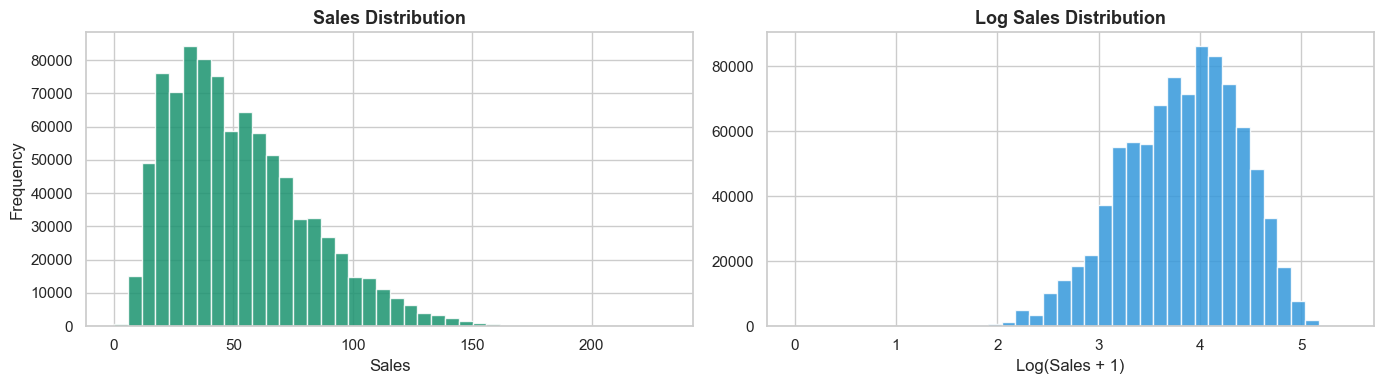

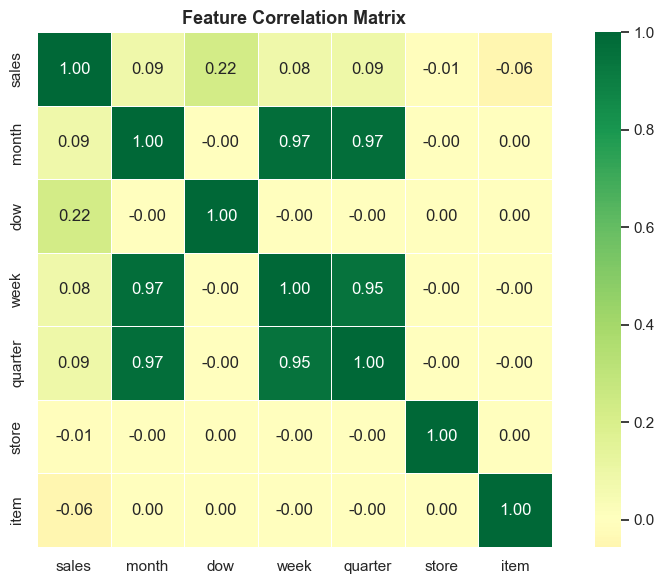

In [29]:
# Cell 11 — Correlation Heatmap & Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(demand['sales'], bins=40, color='#1a936f', edgecolor='white', alpha=0.85)
axes[0].set_title('Sales Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(demand['sales']), bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].set_title('Log Sales Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log(Sales + 1)')

plt.tight_layout()
plt.show()

corr_cols = ['sales', 'month', 'dow', 'week', 'quarter', 'store', 'item']
corr_mat  = demand[corr_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# Cell 12 — Save Processed Data
import os
os.makedirs('../data/processed', exist_ok=True)

demand.to_csv('../data/processed/demand_clean.csv', index=False)
retail.to_csv('../data/processed/retail_clean.csv', index=False)

print('demand_clean.csv saved')
print('retail_clean.csv saved')
print()
print('=== EDA Summary ===')
print(f'Demand records   : {len(demand):,}')
print(f'Retail records   : {len(retail):,}')
print(f'Date range       : {demand["date"].min()} → {demand["date"].max()}')
print(f'Stores           : {demand["store"].nunique()}')
print(f'Items            : {demand["item"].nunique()}')
print(f'Countries        : {retail["Country"].nunique()}')
print(f'Total revenue    : ${retail["Revenue"].sum():,.2f}')

demand_clean.csv saved
retail_clean.csv saved

=== EDA Summary ===
Demand records   : 913,000
Retail records   : 805,549
Date range       : 2013-01-01 00:00:00 → 2017-12-31 00:00:00
Stores           : 10
Items            : 50
Countries        : 41
Total revenue    : $17,743,429.18
